
# Régression linéaire multiple en Python  


Objectif :
Construire, interpréter et évaluer un modèle de **régression linéaire multiple**
en utilisant des **packages standards**.

## Problématique

Les entreprises investissent dans plusieurs canaux publicitaires  
(TV, radio, presse écrite) afin d’augmenter leurs ventes.

La question centrale est la suivante :

> **Comment les budgets publicitaires influencent-ils les ventes ?**

Plus précisément :
- Quel est l’impact de chaque canal publicitaire sur les ventes ?
- Certaines dépenses ont-elles plus d’effet que d’autres ?
- Peut-on estimer les ventes à partir d’un budget publicitaire donné ?

Pour répondre à ces questions, nous utilisons une **régression linéaire multiple**,
qui permet de modéliser la relation entre plusieurs variables explicatives
(budgets publicitaires) et une variable cible continue (ventes).



Jeu de données :
- TV
- Radio
- Newspaper
- Sales (cible)


## 1) Importer les bibliothèques et charger les données

In [1]:
import numpy as np              # Calculs numériques et opérations mathématiques
import pandas as pd             # Manipulation et analyse de données (DataFrame)
import matplotlib.pyplot as plt # Visualisation graphique

from sklearn.model_selection import train_test_split  # Séparation train / test
from sklearn.linear_model import LinearRegression      # Modèle de régression linéaire
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Métriques d'évaluation

import statsmodels.api as sm    # Analyse statistique des modèles (coefficients, p-values)




In [2]:

df = pd.read_csv("data/Advertising.csv")
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9



## 2) Problématique

Comment les budgets publicitaires influencent-ils les ventes ?
Nous cherchons à estimer une relation linéaire entre plusieurs variables explicatives
et une variable cible continue.


## Analyse exploratoire des données

Avant d’entraîner un modèle de régression, il est essentiel de comprendre
la structure des données et les relations entre les variables.

L’analyse univariée consiste à étudier chaque variable individuellement.
Elle permet d’observer :
- les ordres de grandeur
- les distributions
- la présence éventuelle de valeurs atypiques

In [3]:
# Statistiques descriptives
df.describe()


,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


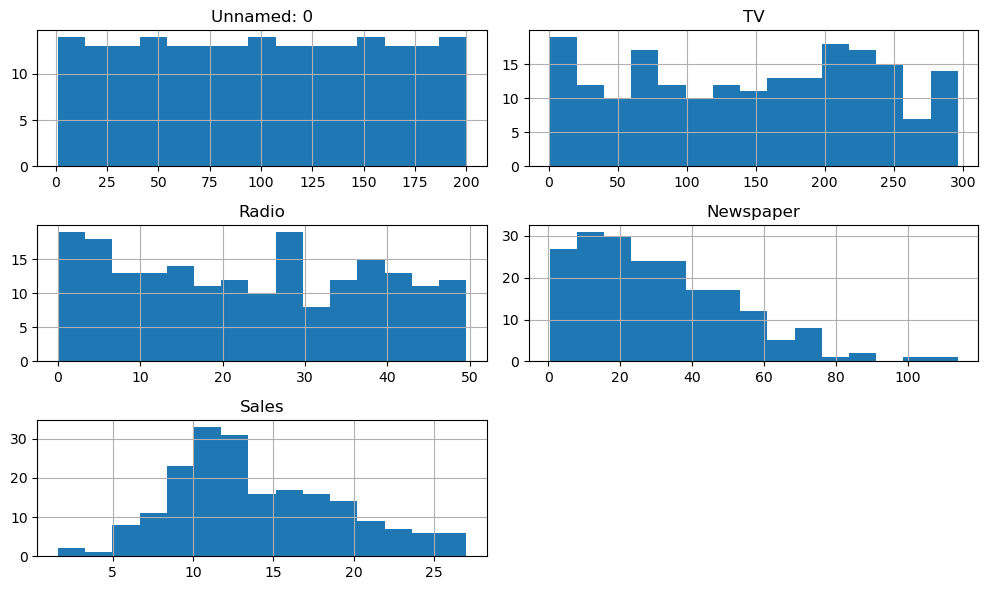

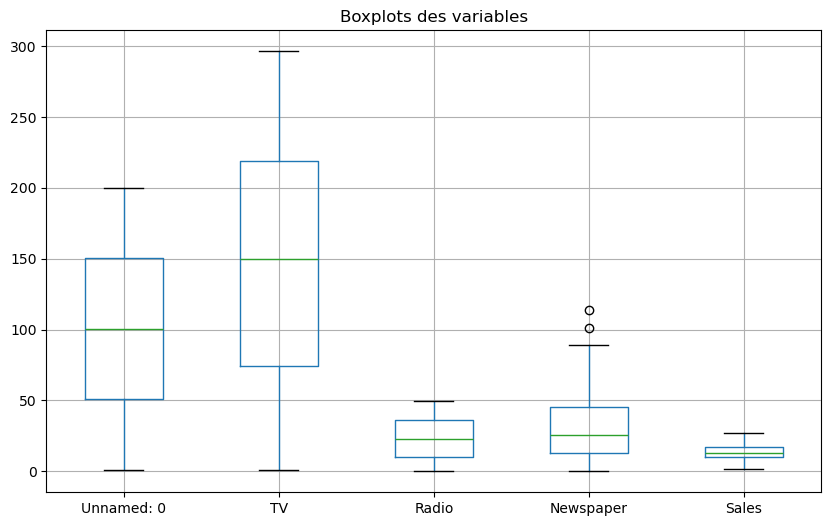

In [4]:
# Histogrammes des variables
df.hist(figsize=(10, 6), bins=15)
plt.tight_layout()
plt.show()


# Boxplots des variables
plt.figure(figsize=(10, 6))
df.boxplot()
plt.title("Boxplots des variables")
plt.show()

In [7]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

### Analyse bivariée : matrice de corrélation

L’analyse bivariée permet d’étudier les relations linéaires entre deux variables.

La matrice de corrélation mesure l’intensité et le sens de la relation linéaire :
- une corrélation proche de **1** indique une relation positive forte
- une corrélation proche de **-1** indique une relation négative forte
- une corrélation proche de **0** indique une relation linéaire faible

Cette étape permet :
- d’identifier les variables les plus liées à la variable cible
- de détecter une éventuelle colinéarité entre variables explicatives

👉 La régression linéaire est pertinente lorsque des relations linéaires
apparaissent dans la matrice de corrélation.

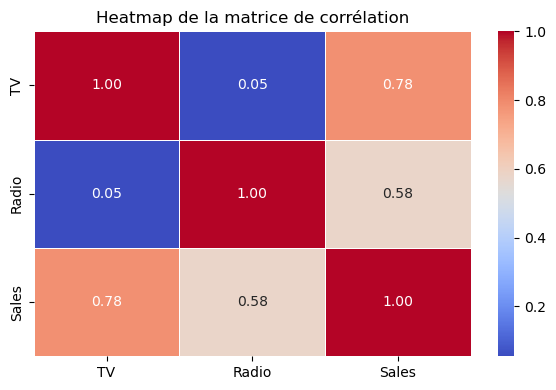

In [16]:
# Visualisation de la matrice de corrélation

import matplotlib.pyplot as plt
import seaborn as sns

# Sélection des variables
df_bis = df[["TV", "Radio","Sales"]]

# Calcul de la matrice de corrélation
corr_matrix = df_bis.corr()

# Heatmap de corrélation
plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_matrix,
    annot=True,          # afficher les coefficients
    cmap="coolwarm",     # palette de couleurs
    fmt=".2f",           # 2 décimales
    linewidths=0.5
)

plt.title("Heatmap de la matrice de corrélation")
plt.tight_layout()
plt.show()


## 3) Séparer les variables explicatives et la variable cible

- **X** : variables explicatives  
  (aussi appelées *variables indépendantes* ou *régresseurs*)

- **y** : variable cible  
  (aussi appelée *variable dépendante* ou *variable à expliquer*)


In [26]:

X = df[["TV", "Radio"]]
y = df["Sales"]


## 4) Régression multiple avec statsmodels

In [27]:

from sklearn.model_selection import train_test_split
import statsmodels.api as sm

# Séparation train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)





In [28]:
# Ajout de la constante (intercept)
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# Entraînement du modèle sur le train
model_sm = sm.OLS(y_train, X_train_sm)
results = model_sm.fit()

# Résumé du modèle
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     673.4
Date:                Wed, 21 Jan 2026   Prob (F-statistic):           9.30e-78
Time:                        21:58:11   Log-Likelihood:                -306.72
No. Observations:                 160   AIC:                             619.4
Df Residuals:                     157   BIC:                             628.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0283      0.330      9.188      0.000       2.377       3.679
TV             0.0447      0.002     28.620      0.000       0.042       0.048
Radio          0.1907      0.009     21.396      0.000       0.173       0.208
==============================================================================
Omnibus:                       68.563   Durbin-Watson:                   2.161
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              250.306
Skew:                          -1.638   Prob(JB):                     4.43e-55
Kurtosis:                       8.179   Cond. No.                         435.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [29]:
# Ajout de la constante (intercept)
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# Entraînement du modèle sur le train
model_sm = sm.OLS(y_train, X_train_sm)
results = model_sm.fit()

# Résumé du modèle
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     673.4
Date:                Wed, 21 Jan 2026   Prob (F-statistic):           9.30e-78
Time:                        21:58:11   Log-Likelihood:                -306.72
No. Observations:                 160   AIC:                             619.4
Df Residuals:                     157   BIC:                             628.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0283      0.330      9.188      0.000       2.377       3.679
TV             0.0447      0.002     28.620      0.000       0.042       0.048
Radio          0.1907      0.009     21.396      0.000       0.173       0.208
==============================================================================
Omnibus:                       68.563   Durbin-Watson:                   2.161
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              250.306
Skew:                          -1.638   Prob(JB):                     4.43e-55
Kurtosis:                       8.179   Cond. No.                         435.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 5) Régression multiple avec scikit-learn

In [30]:

model = LinearRegression()
model.fit(X_train, y_train)

model.coef_, model.intercept_


(array([0.0447283 , 0.19066726]), np.float64(3.028255250783303))

## 6) Interpréter les coefficients

In [31]:

pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
})


,Variable,Coefficient
0,TV,0.044728
1,Radio,0.190667


## 7) Prédictions et évaluation

In [32]:

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mae, mse, r2


(1.444302313822758, 3.137948009068354, 0.9005833101920355)

## 8) Observé vs prédit

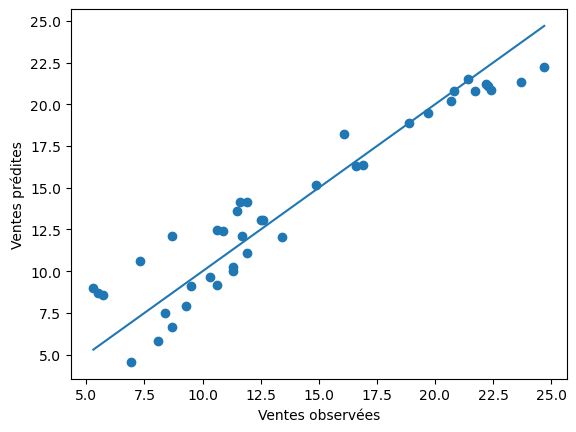

In [33]:

plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Ventes observées")
plt.ylabel("Ventes prédites")
plt.show()


## 9) Exemple de prédiction

In [34]:

nouveau = pd.DataFrame({
    "TV": [150],
    "Radio": [20]
    
})

model.predict(nouveau)


array([13.55084584])

# Métriques d’évaluation en régression

## 1. MAE — Mean Absolute Error
Mesure l’erreur absolue moyenne entre les valeurs observées et les valeurs prédites.

\[
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
\]

- Facile à interpréter
- Peu sensible aux valeurs extrêmes



## 2. MSE — Mean Squared Error
Mesure l’erreur quadratique moyenne.

\[
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
\]

- Pénalise fortement les grandes erreurs
- Très utilisée pour l’optimisation des modèles



## 3. RMSE — Root Mean Squared Error
Racine carrée du MSE.

\[
\text{RMSE} = \sqrt{\text{MSE}}
\]

- S’exprime dans la même unité que la variable cible
- Plus sensible aux valeurs extrêmes que la MAE



## 4. MAPE — Mean Absolute Percentage Error
Mesure l’erreur absolue moyenne en pourcentage.

\[
\text{MAPE} = \frac{100}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|
\]

- Interprétation intuitive (en %)
- Problématique lorsque \( y_i \) est proche de 0



## 5. \( R^2 \) — Coefficient de détermination
Mesure la proportion de la variance de la variable expliquée expliquée par le modèle.

\[
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
\]

- \( R^2 \in [0, 1] \) dans les modèles avec constante
- Plus \( R^2 \) est élevé, meilleure est la qualité d’ajustement


## 6. Corrélation entre les valeurs observées et prédites
Mesure le lien linéaire entre \( y \) et \( \hat{y} \).

\[
\rho(y, \hat{y}) = \frac{\text{Cov}(y, \hat{y})}{\sigma_y \sigma_{\hat{y}}}
\]

- Valeur comprise entre -1 et 1
- Plus la corrélation est proche de 1, meilleur est l’ajustement
- Liée à \( R^2 \) dans le cas d’une régression linéaire simple
